 ## Домашнее задание Проверка гипотез

<div class="alert alert-info">
<b>Задание № 1</b>
    
Разработайте функцию для проверки нормальности распределения выборки данных, используя шаблон ниже. Вы можете использовать один из известных Вам статистических тестов.
</div>

In [2]:
import pandas as pb
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
import math


SyntaxError: invalid syntax (394880174.py, line 8)

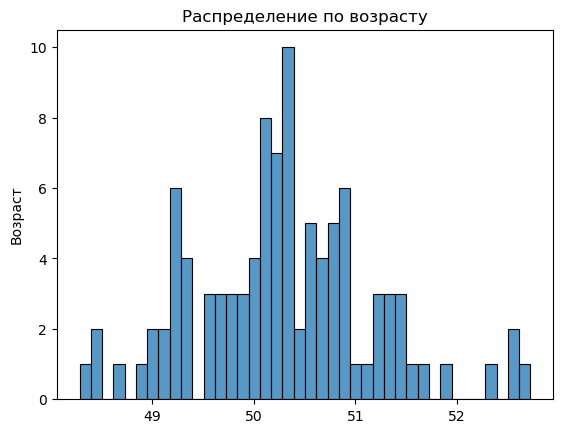

In [7]:

data1 = st.norm.rvs(loc=30, scale=5, size=100)
data2 = st.norm.rvs(loc=50, scale=1, size=100)
sns.histplot(data=data2, bins=40)
plt.title("Распределение по возрасту")
plt.ylabel("Количество человек")
plt.ylabel("Возраст")
plt.show()


In [8]:
def check_normality(data):
   
# результат встроенного теста Шапиро-Уилка 
    stat, p = shapiro(data)
    print(f"Statistic={stat:.3f}, p-value={p:.5f}")
 
    if p < 0.05:
        print("Отклоняем нулевую гипотезу >> Данные распределены не нормально")
    else:
        print("Не отклоняем нулевую гипотезу >> Данные распределены нормально")
check_normality(data1)

Statistic=0.989, p-value=0.58279
Не отклоняем нулевую гипотезу >> Данные распределены нормально


<div class="alert alert-info">
<b>Задание № 2</b>

Даны две выборки роста мужчин и женщин.
- Докажите, используя `t-Тест Стьдента`, что различие между выборками незначительно, если уровень значимости равен $\alpha$ `= 0.001`.
- Покажите различия визуально
- Является ли результат полезным с практической точки зрения? Почему да или нет?
</div>

In [103]:
np.random.seed(42) #фиксация случайности

mens  = st.norm.rvs(loc=171, scale=10, size=150000)  # Выборка мужчин со средним ростом 171
womens = st.norm.rvs(loc=170, scale=10, size=150000)  # Выборка женщин со средним ростом 170
"""Нулевая гипотеза - различие между выборками незначительно"""

'Нулевая гипотеза - различие между выборками незначительно'

In [53]:
## Проверка равенства дисперсий
from scipy.stats import levene

stat, p = levene(mens, womens)
print(f"Levene test p-value: {p:.4f}")

Levene test p-value: 0.6804


Statistic=28.314, p-value=0.00000
Отклоняем нулевую гипотезу >> Различие между выборками значительно


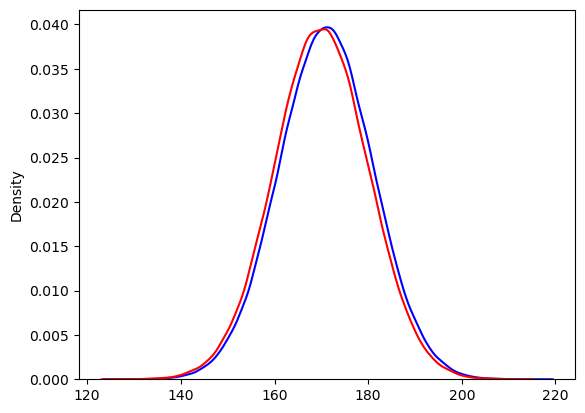

In [68]:
stat, p = st.ttest_ind(mens, womens, equal_var=True)
print(f"Statistic={stat:.3f}, p-value={p:.5f}")
 
if p < 0.001:
    print("Отклоняем нулевую гипотезу >> Различие между выборками значительно")
else:
    print("Не отклоняем нулевую гипотезу >> Различие между выборками незначительно")

sns.kdeplot(mens, color="blue", label="Мужчины")
sns.kdeplot(womens, color="red", label="Женщины")
plt.show()



Вывод: у данных есть существенные отличия. Данный результат является полезным с практической точки зрения, поскольку позволяет сказать, что на такой большой выборке (150000) даже небольшой отличие в росте (1см) делает две выборки сильно отличными от друга друга с данным уровнем значимости. Это не позволяет использовать две выборки одновременно при решении одного определенного класса задач. 

<div class="alert alert-info">
<b>Задание № 3</b>

Специалист по кадрам, работающий в технологической компании, интересуется сверхурочным временем разных команд. Чтобы выяснить, есть ли разница между сверхурочной работой команды разработчиков программного обеспечения и группы тестирования, она случайным образом выбрала 17 сотрудников в каждой из двух команд и записала их среднее сверхурочное время за неделю в пересчете на час. Данные ниже.

В соответствии с этой информацией проведите проверку гипотезы, чтобы проверить, есть ли разница между переутомлением двух команд, используя уровень значимости 0,05. Прежде чем приступать к проверке гипотез, проверьте предположение нормальности.
</div>

In [70]:
test_team = [6.2, 7.1, 1.5, 2,3 , 2, 1.5, 6.1, 2.4, 2.3, 12.4, 1.8, 5.3, 3.1, 9.4, 2.3, 4.1]
developer_team = [2.3, 2.1, 1.4, 2.0, 8.7, 2.2, 3.1, 4.2, 3.6, 2.5, 3.1, 6.2, 12.1, 3.9, 2.2, 1.2 ,3.4]

In [74]:
check_normality(test_team)
check_normality(developer_team)

Statistic=0.825, p-value=0.00462
Отклоняем нулевую гипотезу >> Данные распределены не нормально
Statistic=0.753, p-value=0.00049
Отклоняем нулевую гипотезу >> Данные распределены не нормально


Statistic=151.500, p-value=0.82265
Не отклоняем нулевую гипотезу >> Различия между переутомлением нет


<Axes: ylabel='Density'>

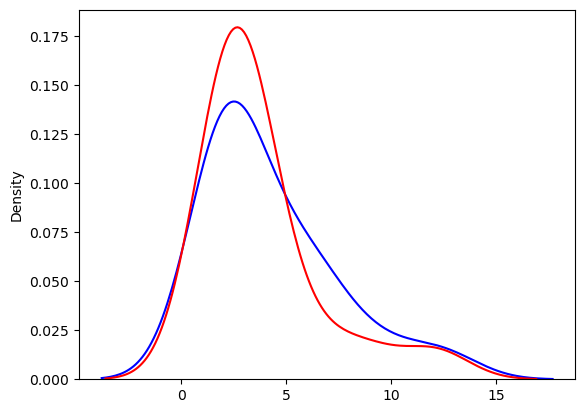

In [80]:
"""Следовательно, будем использовать критерий Манна-Уитни"""
"""Нулевая гипотеза = разницы между переутомлением нет"""
stat, p = st.mannwhitneyu(test_team, developer_team)
print(f"Statistic={stat:.3f}, p-value={p:.5f}")
 
if p < 0.05:
    print("Отклоняем нулевую гипотезу >> Различие между переутомлением есть")
else:
    print("Не отклоняем нулевую гипотезу >> Различия между переутомлением нет")

sns.kdeplot(test_team, color="blue", label="Мужчины")
sns.kdeplot(developer_team, color="red", label="Женщины")

<div class="alert alert-info">
<b>Задание № 4</b>

Педиатр хочет увидеть влияние потребления смеси на среднемесячную прибавку в весе у новорожденных. По этой причине она собрала данные из трех разных групп. Первая группа – дети исключительно грудного вскармливания, вторая группа – дети, которых кормят только смесью, и последняя группа – это дети, находящиеся на искусственном вскармливании и на грудном вскармливании. Эти данные приведены ниже.

В соответствии с этой информацией проведите проверку гипотезы, чтобы проверить, есть ли разница между среднемесячным приростом этих трех групп, используя уровень значимости 0,05. Если есть значительная разница, выполните дальнейший анализ, чтобы найти причину разницы.
</div>

In [3]:
only_breast = [794.1, 716.9, 993. , 724.7, 760.9, 908.2, 659.3 , 690.8, 768.7, 717.3 , 630.7, 729.5, 714.1, 810.3, 583.5, 679.9, 865.1]
only_formula = [898.8, 881.2, 940.2, 966.2, 957.5, 1061.7, 1046.2, 980.4, 895.6, 919.7, 1074.1, 952.5, 796.3, 859.6, 871.1 , 1047.5, 919.1 , 1160.5, 996.9]
both = [976.4, 656.4, 861.2, 706.8, 718.5, 717.1, 759.8, 894.6, 867.6, 805.6, 765.4, 800.3, 789.9, 875.3, 740. , 799.4, 790.3, 795.2 , 823.6, 818.7, 926.8, 791.7, 948.3]

In [9]:
check_normality(only_breast)
check_normality(only_formula)
check_normality(both)

Statistic=0.951, p-value=0.46942
Не отклоняем нулевую гипотезу >> Данные распределены нормально
Statistic=0.976, p-value=0.88790
Не отклоняем нулевую гипотезу >> Данные распределены нормально
Statistic=0.975, p-value=0.79730
Не отклоняем нулевую гипотезу >> Данные распределены нормально


In [32]:
"""Нулевая гипотеза - разницы между среднемесячным приростом этих групп нет"""
f_stat, p = st.f_oneway(only_breast, only_formula, both)

if p < 0.05:
    print("Отклоняем нулевую гипотезу >> Различие между выборками значительно")
else:
    print("Не отклоняем нулевую гипотезу >> Различие между выборками незначительно")

"""Найдем, между какими группами есть отличия"""

values = only_formula + only_breast + both
print(len(both))
groups = ['A'] * 19 + ['B'] * 17 + ['C'] * 23

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=values, groups=groups, alpha=0.05)
print(tukey)
"""Причина разницы - сильные отличия межлу средними"""



Отклоняем нулевую гипотезу >> Различие между выборками значительно
23
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     A      B -209.3923    0.0 -281.4337 -137.3508   True
     A      C -149.2636    0.0 -216.1621  -82.3651   True
     B      C   60.1286 0.0995   -8.8912  129.1485  False
---------------------------------------------------------


'Причина разницы - сильные отличия межлу средними'

Сделаем визуализацию данных

0    749.823529
dtype: float64

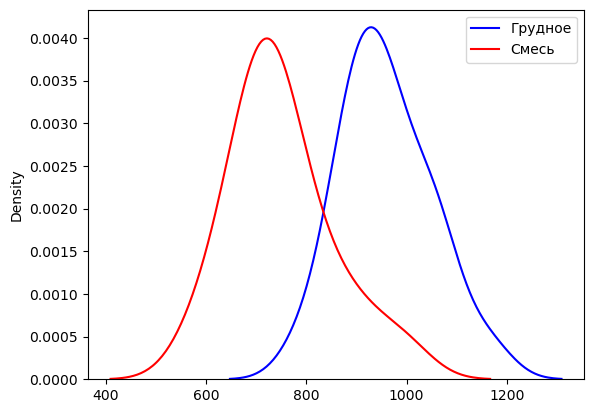

In [98]:
"""1. сравним две выборки: вес детей, которых кормят только грудью, и детей, которых кормят только смесью"""
sns.kdeplot(only_formula, color="blue", label="Грудное")
sns.kdeplot(only_breast, color="red", label="Смесь")
plt.legend()
"""По графикам видно, что средние значения очень сильно сдвинуты друг от друга. У детей, которые находятся на грудном вскармливании среднее значение прибавление в весе больше, чем у детей на смеси"""
data_formula = pb.DataFrame(only_formula)
data_breast = pb.DataFrame(only_breast)
data_formula.mean()
data_breast.mean()

0    809.952174
dtype: float64

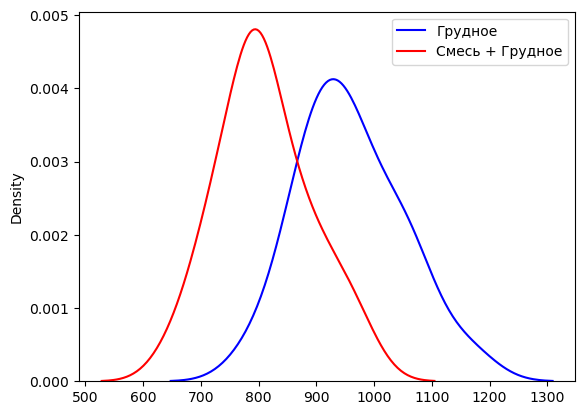

In [100]:
"""2. сравним две выборки: вес детей, которых кормят только грудью, и детей, которых кормят грудью и смесью"""
sns.kdeplot(only_formula, color="blue", label="Грудное")
sns.kdeplot(both, color="red", label="Смесь + Грудное")
plt.legend()
"""По графикам видно, что средние значения очень сильно сдвинуты друг от друга. У детей, которые находятся на грудном вскармливании среднее значение прибавления в весе больше, чем у детей на смеси + грудном вскармливании"""
data_formula = pb.DataFrame(only_formula)
data_both = pb.DataFrame(both)
data_formula.mean()
data_both.mean()

0    809.952174
dtype: float64

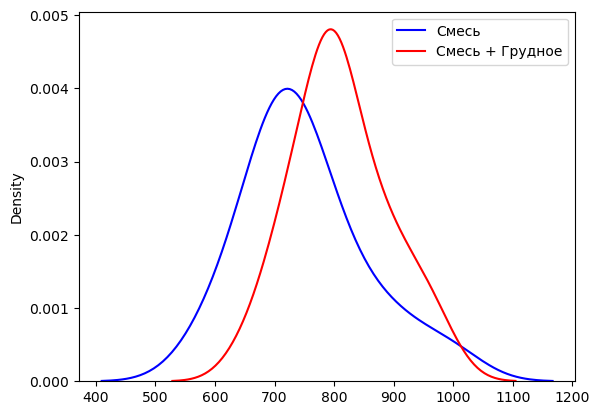

In [102]:
"""2. сравним две выборки: вес детей, которых кормят только смесью, и детей, которых кормят грудью и смесью"""
sns.kdeplot(only_breast, color="blue", label="Смесь")
sns.kdeplot(both, color="red", label="Смесь + Грудное")
plt.legend()
"""По графикам видно, что средние значения очень сильно сдвинуты друг от друга. У детей, которые находятся на грудном вскармливании + смеси среднее значение прибавления в весе больше, чем у детей только на смеси"""

data_breast.mean()
data_both.mean()

Вывод: дети, которые находятся на смесевом кормлении, прибывляют в весе меньше, чем дети на других видах кормления.

<div class="alert alert-info">
<b>Задание № 5 (Опционально) </b>

Аналитик финансовой инвестиционной компании интересуется взаимосвязью между полом и склонностью к риску. Из базы данных была взята случайная выборка из 660 клиентов. Клиенты в выборке были классифицированы в соответствии с их полом и склонностью к риску. Результат приведен в следующей таблице.
    
Проверьте гипотезу о том, что склонность к риску клиентов этой компании не зависит от их пола. Используйте α = 0.01.    
</div>

In [105]:
contingency_table = pb.DataFrame(
    [
        [53, 23, 30, 36, 88],
        [71, 48, 51, 57, 203]
    ],
    index = ['Ж', 'М'])

print('Уровень риска')
print(contingency_table)

Уровень риска
    0   1   2   3    4
Ж  53  23  30  36   88
М  71  48  51  57  203


In [112]:
"""Использование коэффициента Пирсона - хи-квадрат"""
"""Нулевая гипотеза - склонность клиентов к риску не связана с полом"""
chi, pval, dof, exp = st.chi2_contingency(contingency_table.values) #Критерий Пирсона (хи квадрат)


print(f"p-value = {pval:.6f}, уровень значимости = {0.01}")
if pval < 0.01:
    print("Отклоняем нулевую гипотезу >> Склонность риска связана с полом")
else:
    print("Не отклоняем нулевую гипотезу >> Склонность риска не связана с полом")




p-value = 0.130992, уровень значимости = 0.01
Не отклоняем нулевую гипотезу >> Склонность риска не связана с полом


<div class="alert alert-info">
<b>Задание № 6 (Опционально)</b>

Компания электронной коммерции регулярно размещает рекламу своих кампаний на YouTube, Instagram и Facebook. Однако новому менеджеру было любопытно, есть ли разница между количеством клиентов, привлеченных этими платформами. Поэтому она начала использовать Adjust — приложение, позволяющее узнать, откуда приходят ваши пользователи. Ежедневные цифры, сообщаемые Adjust для каждой платформы, приведены ниже.
    
В соответствии с этой информацией проведите проверку гипотез, чтобы проверить, есть ли разница между средним числом привлеченных клиентов на этих трех платформах с использованием уровня значимости 0,05. Если есть значительная разница, выполните дальнейший анализ, чтобы найти причину разницы. Прежде чем приступать к проверке гипотез, проверьте соответствующие предположения.
</div>

In [22]:
youtube=[1913, 1879, 1939, 2146, 2040, 2127, 2122, 2156, 2036, 1974, 1956, 2146, 2151, 1943, 2125]
instagram = [2305., 2355., 2203., 2231., 2185., 2420., 2386., 2410., 2340., 2349., 2241., 2396., 2244., 2267., 2281.]
facebook = [2133., 2522., 2124., 2551., 2293., 2367., 2460., 2311., 2178., 2113., 2048., 2443., 2265., 2095., 2528.]

In [115]:
"""Предположение -  разница между площадками есть  - больше людей приходят с инстаграма"""

check_normality(youtube)
check_normality(instagram)
check_normality(facebook)

Statistic=0.865, p-value=0.02854
Отклоняем нулевую гипотезу >> Данные распределены не нормально
Statistic=0.943, p-value=0.41558
Не отклоняем нулевую гипотезу >> Данные распределены нормально
Statistic=0.917, p-value=0.17158
Не отклоняем нулевую гипотезу >> Данные распределены нормально


так как одна выборка распредлена не нормально, то будем использовать Критерий Краскал–Уоллис и Post-hoc Dunn's test для анализа результатов теста Краскала-Уоллиса

In [24]:
"""Нулевая гипотеза - различие между выборками незначительно"""
from scipy.stats import kruskal
stat, p = kruskal(youtube, instagram, facebook)


print(f"Статистика = {stat:.5f}, p = {p:.5f}")
if p < 0.05:
    print("Отклоняем нулевую гипотезу >> Различие между выборками значительно")
else:
    print("Не отклоняем нулевую гипотезу >> Различие между выборками незначительно")




Статистика = 22.19354, p = 0.00002
Отклоняем нулевую гипотезу >> Различие между выборками значительно


In [26]:
"""Найдет различия между выборками с помощью Post-hoc Dunn's test """
import scikit_posthocs as sp
data = pb.DataFrame({
    'значение': youtube + instagram + facebook,
    'группа':   ['A'] * len(youtube) + ['B'] * len(instagram) + ['C'] * len(facebook)
})

# Выполняем Dunn's тест с поправкой на множественные сравнения (Bonferroni, Holm и др.)
dunn_result = sp.posthoc_dunn(data, val_col='значение', group_col='группа', p_adjust='bonferroni') ## p_adjust='bonferroni' - поправка на множественные сравнения

print(dunn_result)

"""Там, где значения < 0,05, есть различия"""


          A         B         C
A  1.000000  0.000041  0.000553
B  0.000041  1.000000  1.000000
C  0.000553  1.000000  1.000000


Вывод: с инстаграма и фейсбука приходит примерно одинаковое количество людей, с ютуба - меньше

Сделаем визуализацию данных

среднее количество пользователь, перешедших на рекламу: с инстаграма 2043.53, с ютуба - 2307.53 


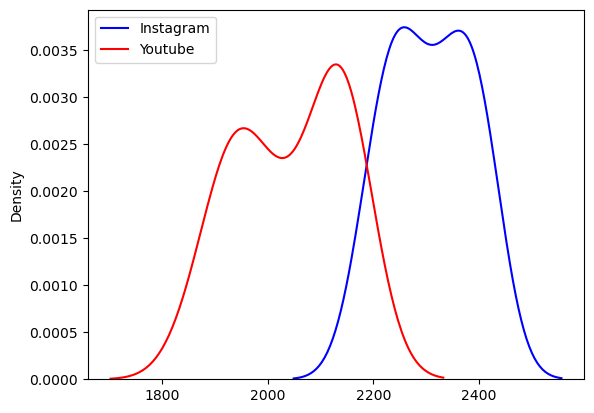

In [29]:
"""1. сравним две выборки: количество людей, пришедших с ютуба и с инстаграма"""
sns.kdeplot(instagram, color="blue", label="Instagram")
sns.kdeplot(youtube, color="red", label="Youtube")
plt.legend()
"""По графикам видно, что средние значения очень сильно сдвинуты друг от друга. У детей, которые находятся на грудном вскармливании среднее значение прибавление в весе больше, чем у детей на смеси"""
data_youtube = pb.DataFrame(instagram)
data_inst = pb.DataFrame(youtube)
print(f"среднее количество пользователь, перешедших на рекламу: с инстаграма {data_inst.mean()[0]:.2f}, с ютуба - {data_youtube.mean()[0]:.2f} ")

среднее количество пользователь, перешедших на рекламу: с фейсбука 2295.40, с ютуба - 2307.53 


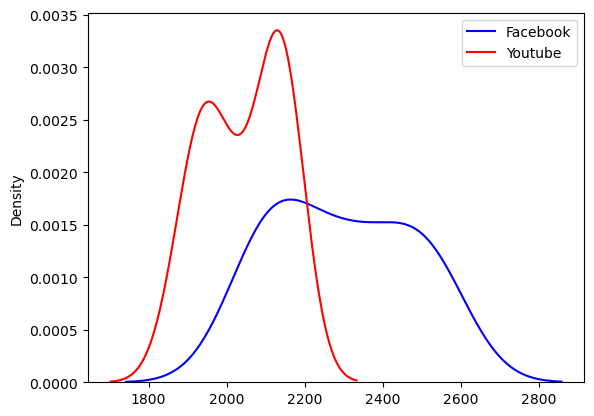

In [30]:
"""2. сравним две выборки: количество людей, пришедших с ютуба и с фейсбука"""
sns.kdeplot(facebook, color="blue", label="Facebook")
sns.kdeplot(youtube, color="red", label="Youtube")
plt.legend()
"""По графикам видно, что средние значения очень сильно сдвинуты друг от друга. У детей, которые находятся на грудном вскармливании среднее значение прибавление в весе больше, чем у детей на смеси"""
data_facebook = pb.DataFrame(facebook)
print(f"среднее количество пользователь, перешедших на рекламу: с фейсбука {data_facebook.mean()[0]:.2f}, с ютуба - {data_youtube.mean()[0]:.2f} ")

среднее количество пользователь, перешедших на рекламу: с фейсбука 2295.40, с инстаграма - 2043.53 


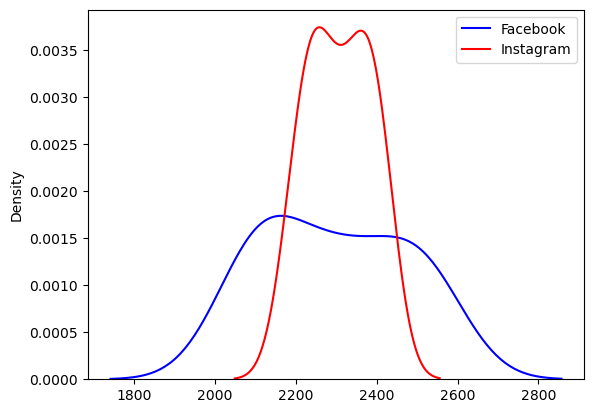

In [31]:
"""3. сравним две выборки: количество людей, пришедших с инстаграма и с фейсбука"""
sns.kdeplot(facebook, color="blue", label="Facebook")
sns.kdeplot(instagram, color="red", label="Instagram")
plt.legend()
"""По графикам видно, что средние значения очень сильно сдвинуты друг от друга. У детей, которые находятся на грудном вскармливании среднее значение прибавление в весе больше, чем у детей на смеси"""
print(f"среднее количество пользователь, перешедших на рекламу: с фейсбука {data_facebook.mean()[0]:.2f}, с инстаграма - {data_inst.mean()[0]:.2f} ")

# **Примечание:**

Домашнее задание сдается ссылкой [Google Colab](https://colab.research.google.com/). Мы не сможем проверить его или помочь, если вы пришлете:

*   файлы;
*   архивы;
*   скриншоты кода.

Все обсуждения и консультации по выполнению домашнего задания ведутся только на соответствующем канале в Discord.

**Как правильно задавать вопросы аспирантам, преподавателям и коллегам:**

Прежде чем задать вопрос, попробуйте найти ответ в интернете. Навык самостоятельного поиска информации — один из важнейших. Каждый практикующий специалист любого уровня делает это ежедневно.

Сформулируйте вопрос по алгоритму:

1.   Что я делаю?
2.   Какого результата я ожидаю?
3.   Как фактический результат отличается от ожидаемого?
4.   Что я уже попробовал сделать, чтобы исправить проблему?

По возможности прикрепите к вопросу скриншоты либо ссылки на код. Не выкладывайте все решение, оставляйте только проблемный и воспроизводимый участок кода.